In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter

import pandas as pd
import numpy as np

from scipy import stats

In [30]:
file_path = './datasets/Top_spotify_songs.csv'
df_new = pd.read_csv(file_path)

In [31]:
print(df_new.tail())

                     spotify_id                               name  \
1728377  0AYt6NMyyLd0rLuvr0UkMH          Slime You Out (feat. SZA)   
1728378  2Gk6fi0dqt91NKvlzGsmm7  SAY MY GRACE (feat. Travis Scott)   
1728379  26b3oVLrRUaaybJulow9kz                             People   
1728380  5ydjxBSUIDn26MFzU3asP4                         Rainy Days   
1728381  59NraMJsLaMCVtwXTSia8i                              Prada   

                             artists  daily_rank  daily_movement  \
1728377                   Drake, SZA          46               4   
1728378         Offset, Travis Scott          47               3   
1728379                     Libianca          48               2   
1728380                            V          49               1   
1728381  cassö, RAYE, D-Block Europe          50               0   

         weekly_movement country snapshot_date  popularity  is_explicit  ...  \
1728377                0      AE    2023-10-18          84         True  ...   
1728378   

In [32]:
num_rows, num_columns = df_new.shape

print(f"{num_rows=}")
print(f"{num_columns=}")

num_rows=1728382
num_columns=25


In [33]:
df_new.head(60)

,spotify_id,name,artists,daily_rank,daily_movement,weekly_movement,country,snapshot_date,popularity,is_explicit,...,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
0,2plbrEY59IikOBgBGLjaoe,Die With A Smile,"Lady Gaga, Bruno Mars",1,1,0,NaN,2025-02-17,98,False,...,6,-7.777,0,0.0304,0.308000,0.000000,0.1220,0.53500,157.969,3
1,2CGNAOSuO1MEFCbBRgUzjd,luther (with sza),"Kendrick Lamar, SZA",2,1,4,NaN,2025-02-17,90,False,...,2,-7.546,1,0.1250,0.251000,0.000000,0.2480,0.57600,138.008,4
2,6AI3ezQ4o3HUoP6Dhudph3,Not Like Us,Kendrick Lamar,3,-2,8,NaN,2025-02-17,92,True,...,1,-7.001,1,0.0776,0.010700,0.000000,0.1410,0.21400,101.061,4
3,4wJ5Qq0jBN4ajy7ouZIV1c,APT.,"ROSÉ, Bruno Mars",4,0,-2,NaN,2025-02-17,89,False,...,0,-4.477,0,0.2600,0.028300,0.000000,0.3550,0.93900,149.027,4
4,6dOtVTDdiauQNBQEDOtlAB,BIRDS OF A FEATHER,Billie Eilish,5,1,-2,NaN,2025-02-17,96,False,...,2,-10.171,1,0.0358,0.200000,0.060800,0.1170,0.43800,104.978,4
5,3GCdLUSnKSMJhs4Tj6CV3s,All The Stars (with SZA),"Kendrick Lamar, SZA",6,-1,23,NaN,2025-02-17,90,True,...,8,-4.946,1,0.0599,0.061200,0.000195,0.0926,0.55700,96.782,4
6,3sK8wGT43QFpWrvNQsrQya,DtMF,Bad Bunny,7,0,-3,NaN,2025-02-17,97,True,...,7,-27.405,0,0.0717,0.177000,0.218000,0.0807,0.03200,136.020,4
7,0aB0v4027ukVziUGwVGYpG,tv off (feat. lefty gunplay),"Kendrick Lamar, Lefty Gunplay",8,0,13,NaN,2025-02-17,92,True,...,6,-6.679,0,0.2630,0.083700,0.000000,0.4230,0.54800,100.036,4
8,2lTm559tuIvatlT1u0JYG2,BAILE INoLVIDABLE,Bad Bunny,9,0,-2,NaN,2025-02-17,94,True,...,10,-46.113,1,0.0615,0.192000,0.790000,0.1120,0.21900,119.387,3
9,7ne4VBA60CxGM75vw0EYad,That’s So True,Gracie Abrams,10,0,-2,NaN,2025-02-17,94,True,...,1,-4.169,1,0.0368,0.214000,0.000000,0.1590,0.37200,108.548,4


In [34]:
df_new['snapshot_date'] = pd.to_datetime(df_new['snapshot_date'])

df_new['year'] = df_new['snapshot_date'].dt.year

df_new['year']

print(f'Анализ проведён по данным с {min(df_new["year"])} по {max(df_new["year"])} год')
print(f'Количество строк в таблице - {len(df_new["name"].dropna())}')
print(f'Количество треков - {len(df_new.drop_duplicates("spotify_id"))}')
print(f'Разница между ними - {len(df_new) - len(df_new.drop_duplicates("spotify_id"))} (возможно, это повторяющиеся треки в разные дни)')

print(f'''
Столбцы в таблице и что они означают:
spotify_id: Уникальный код трека.
name: Название песни.
artists: Исполнители.
daily_rank / daily_movement / weekly_movement: Место в чарте и его изменение за день/неделю.
popularity: Число от 0 до 100 (алгоритмическая оценка популярности сервисом).
is_explicit: Наличие ненормативной лексики (True/False).
key: Тональность (0 = C, 1 = C#, 2 = D и т.д.).
mode: Мажор (1) или минор (0).
tempo: Темп в BPM (ударов в минуту).
time_signature: Музыкальный размер (обычно 4/4).
danceability: Насколько под трек удобно танцевать (ритм, темп).
energy: Интенсивность и активность (громкость, шум).
loudness: Общая громкость в децибелах (обычно от -60 до 0).
speechiness: Наличие слов. Если > 0.66 — это, скорее всего, подкаст или рэп.
acousticness: Вероятность того, что трек акустический (гитара, пианино) без электроники.
instrumentalness: Вероятность того, что в треке нет вокала.
liveness: Вероятность того, что это запись живого выступления.
valence: «Позитивность» трека. Высокое значение — радость, низкое — грусть/апатия.''')

Анализ проведён по данным с 2023 по 2025 год
Количество строк в таблице - 1728352
Количество треков - 20570
Разница между ними - 1707812 (возможно, это повторяющиеся треки в разные дни)

Столбцы в таблице и что они означают:
spotify_id: Уникальный код трека.
name: Название песни.
artists: Исполнители.
daily_rank / daily_movement / weekly_movement: Место в чарте и его изменение за день/неделю.
popularity: Число от 0 до 100 (алгоритмическая оценка популярности сервисом).
is_explicit: Наличие ненормативной лексики (True/False).
key: Тональность (0 = C, 1 = C#, 2 = D и т.д.).
mode: Мажор (1) или минор (0).
tempo: Темп в BPM (ударов в минуту).
time_signature: Музыкальный размер (обычно 4/4).
danceability: Насколько под трек удобно танцевать (ритм, темп).
energy: Интенсивность и активность (громкость, шум).
loudness: Общая громкость в децибелах (обычно от -60 до 0).
speechiness: Наличие слов. Если > 0.66 — это, скорее всего, подкаст или рэп.
acousticness: Вероятность того, что трек акустичес

In [35]:
print(len(df_new))
print(len(df_new.drop_duplicates('spotify_id')))

1728382
20570


In [36]:
df_corr_mode = pd.DataFrame()
df_corr_mode['Tempo'] = df_new.drop_duplicates('spotify_id')['tempo']
df_corr_mode['Mode'] = df_new.drop_duplicates('spotify_id')['mode']
df_corr_mode['Key'] = df_new.drop_duplicates('spotify_id')['key']
df_corr_mode['Explicit'] = df_new.drop_duplicates('spotify_id')['is_explicit']



mode_counts = df_corr_mode['Mode'].value_counts()
exp_counts = df_corr_mode['Explicit'].value_counts()

print(mode_counts,'\n\n\n')

df_corr_mode.dropna()

print(df_corr_mode)

Mode
1    10538
0    10032
Name: count, dtype: int64 



           Tempo  Mode  Key  Explicit
0        157.969     0    6     False
1        138.008     1    2     False
2        101.061     1    1      True
3        149.027     0    0     False
4        104.978     1    2     False
...          ...   ...  ...       ...
1723478  124.017     0   10      True
1723481  139.987     0    5     False
1724040  113.991     0   10      True
1724386  119.894     1    2     False
1724390  146.641     1   11     False

[20570 rows x 4 columns]


In [37]:
df_corr_mode['Key'].replace(0,'C',inplace=True)
df_corr_mode['Key'].replace(1,'C#',inplace=True)
df_corr_mode['Key'].replace(2,'D',inplace=True)
df_corr_mode['Key'].replace(3,'D#',inplace=True)
df_corr_mode['Key'].replace(4,'E',inplace=True)
df_corr_mode['Key'].replace(5,'F',inplace=True)
df_corr_mode['Key'].replace(6,'F#',inplace=True)
df_corr_mode['Key'].replace(7,'G',inplace=True)
df_corr_mode['Key'].replace(8,'G#',inplace=True)
df_corr_mode['Key'].replace(9,'A',inplace=True)
df_corr_mode['Key'].replace(10,'A#',inplace=True)
df_corr_mode['Key'].replace(11,'B',inplace=True)

df_corr_mode['Mode'].replace(0,'Min',inplace=True)
df_corr_mode['Mode'].replace(1,'Maj',inplace=True)

df_corr_mode['Key Mode'] = df_corr_mode['Key'].astype(str) + df_corr_mode['Mode'].astype(str)


df_corr_mode

/var/folders/6c/nb34s1dx6cz79c3qmcxbd4jh0000gn/T/ipykernel_77873/3829169799.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_corr_mode['Key'].replace(0,'C',inplace=True)
/var/folders/6c/nb34s1dx6cz79c3qmcxbd4jh0000gn/T/ipykernel_77873/3829169799.py:14: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values alwa

,Tempo,Mode,Key,Explicit,Key Mode
0,157.969,Min,F#,False,F#Min
1,138.008,Maj,D,False,DMaj
2,101.061,Maj,C#,True,C#Maj
3,149.027,Min,C,False,CMin
4,104.978,Maj,D,False,DMaj
...,...,...,...,...,...
1723478,124.017,Min,A#,True,A#Min
1723481,139.987,Min,F,False,FMin
1724040,113.991,Min,A#,True,A#Min
1724386,119.894,Maj,D,False,DMaj


In [38]:
df_feat = pd.DataFrame()
df_feat['Name'] = df_new.drop_duplicates('spotify_id')['name']
df_feat['Author'] = df_new.drop_duplicates('spotify_id')['artists']

df_feat['Feat'] = df_new.drop_duplicates('spotify_id')['artists'].str.contains(',')>0

df_feat.head()

,Name,Author,Feat
0,Die With A Smile,"Lady Gaga, Bruno Mars",True
1,luther (with sza),"Kendrick Lamar, SZA",True
2,Not Like Us,Kendrick Lamar,False
3,APT.,"ROSÉ, Bruno Mars",True
4,BIRDS OF A FEATHER,Billie Eilish,False


In [39]:
tempo_data = df_new.drop_duplicates('spotify_id')['tempo'].dropna()

observed_frequencies, bin_edges = np.histogram(tempo_data, bins='auto')

mu, sigma = stats.norm.fit(tempo_data)

expected_probs = stats.norm.cdf(bin_edges[1:], mu, sigma) - stats.norm.cdf(bin_edges[:-1], mu, sigma)

expected_probs /= expected_probs.sum()


expected_frequencies = expected_probs * len(tempo_data)

chi2_stat, p_val = stats.chisquare(observed_frequencies, f_exp=expected_frequencies)

print(f"Статистика Хи-квадрат: {chi2_stat:.4f}")
print(f"P-value: {p_val:.4e}") 
print('Так как P-value < 0.05 мы отвергаем нулевую гипотезу и получаем, что данные распределены не нормально.')

Статистика Хи-квадрат: 2993.1350
P-value: 0.0000e+00
Так как P-value < 0.05 мы отвергаем нулевую гипотезу и получаем, что данные распределены не нормально.


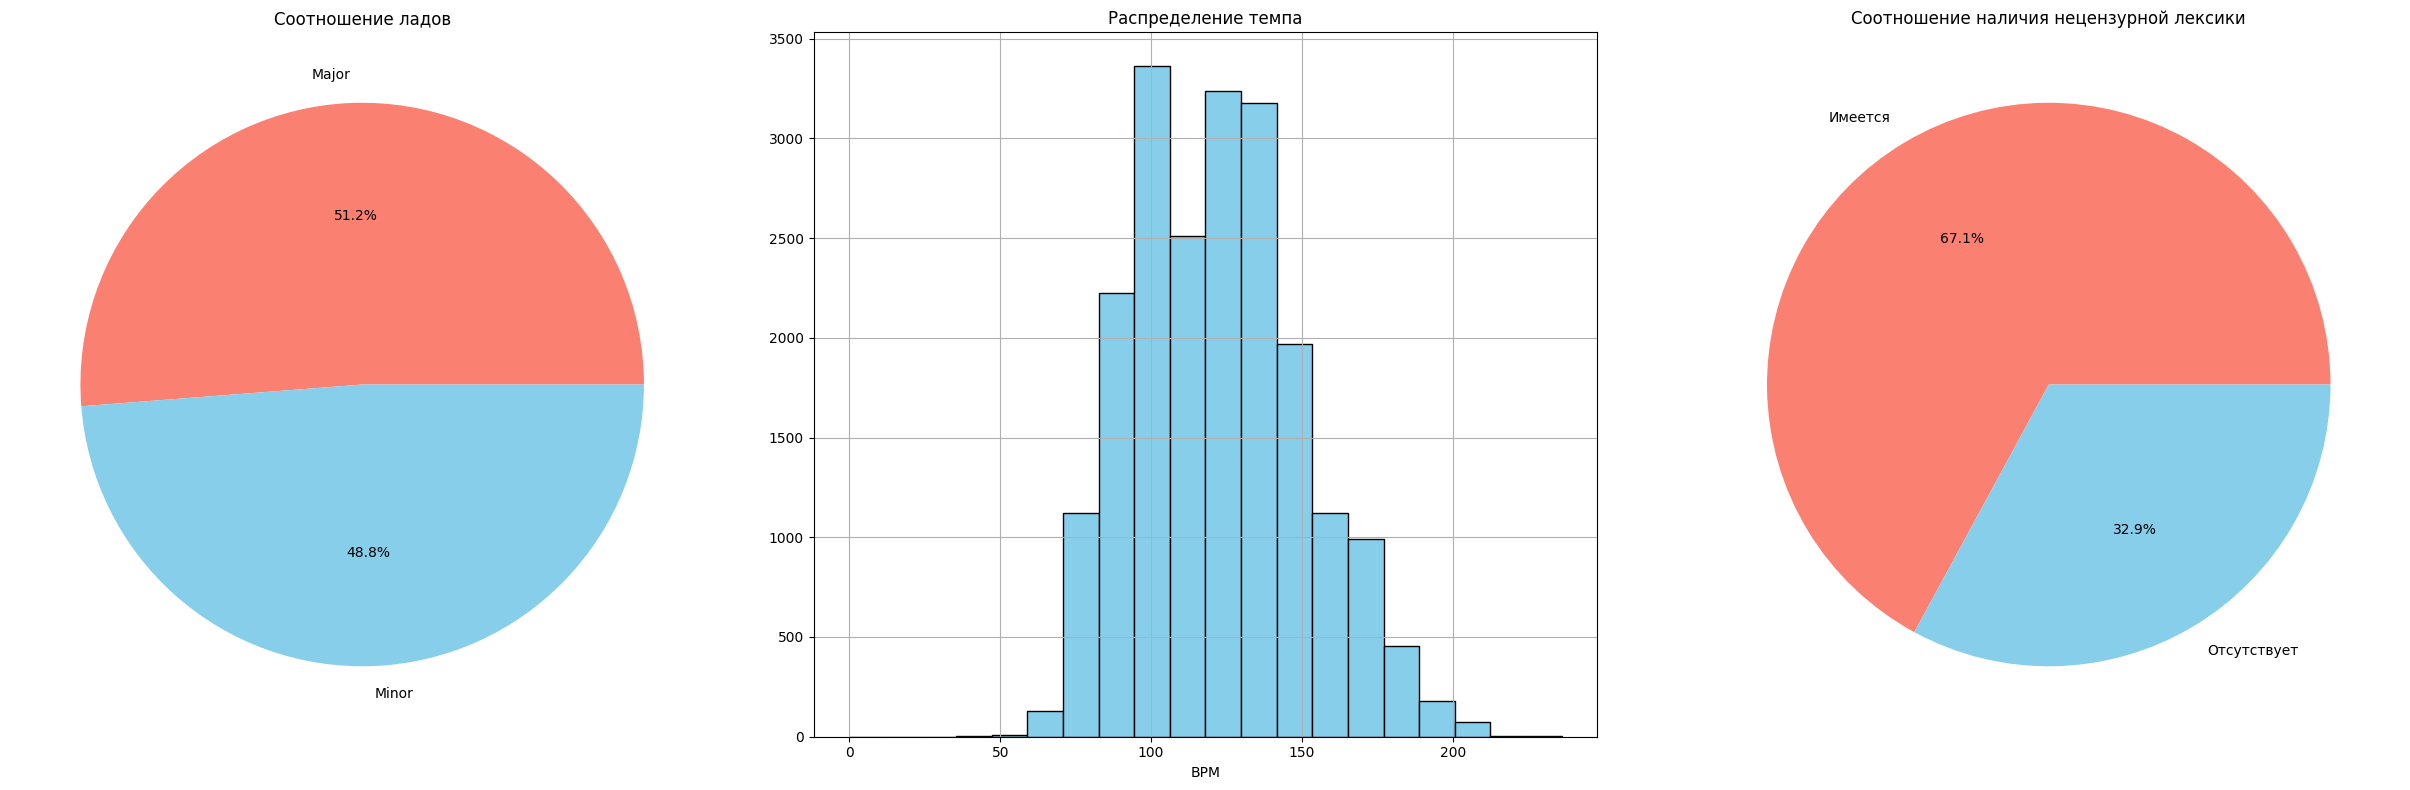

In [40]:
fig, axes = plt.subplots(1, 3, figsize=(25, 8))

df_corr_mode['Tempo'].hist(bins=20, ax=axes[1], color='skyblue', edgecolor='black')
axes[1].set_title('Распределение темпа')
axes[1].set_xlabel('BPM')


mode_counts.plot.pie(
    ax=axes[0], 
    autopct='%1.1f%%', 
    labels=['Major', 'Minor'], 
    colors=['salmon', 'skyblue']
)
axes[0].set_title('Соотношение ладов')
axes[0].set_ylabel('')


exp_counts.plot.pie(
    ax=axes[2],
    autopct='%1.1f%%', 
    labels=['Имеется', 'Отсутствует'], 
    colors=['salmon', 'skyblue']
)
axes[2].set_title('Соотношение наличия нецензурной лексики')
axes[2].set_ylabel('')


plt.tight_layout()
plt.show()

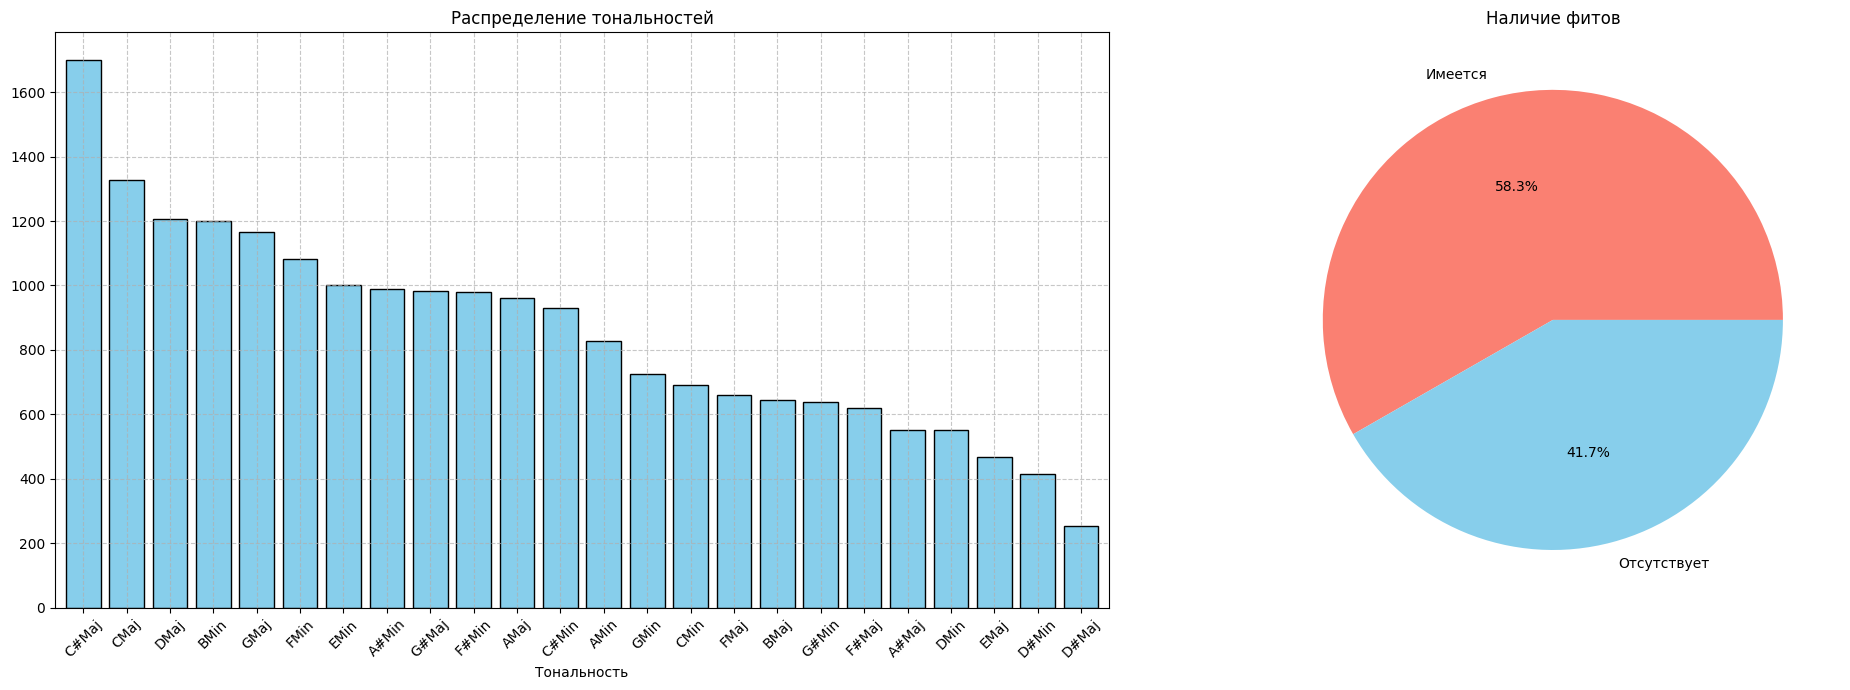

In [41]:

mode_counts = df_corr_mode['Key Mode'].value_counts()
feat_counts = df_feat['Feat'].value_counts()



fig, axes = plt.subplots(1, 2, figsize=(21, 7)) 


mode_counts.plot(kind='bar',
                ax=axes[0],
                color='skyblue', 
                edgecolor='black', 
                width=0.8)

axes[0].set_title('Распределение тональностей')
axes[0].set_xlabel('Тональность')
axes[0].tick_params(axis='x', rotation=45) 
axes[0].grid(axis='y', linestyle='--', alpha=0.7)
axes[0].grid(axis='x', linestyle='--',alpha=0.7)


feat_counts.plot.pie(
    ax=axes[1],
    autopct='%1.1f%%', 
    labels=['Имеется', 'Отсутствует'], 
    colors=['salmon', 'skyblue']
)
axes[1].set_title('Наличие фитов')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()


In [42]:
df_mood = pd.DataFrame()
df_mood['Name'] = df_new.drop_duplicates('spotify_id')['name']
df_mood['Valence'] = df_new.drop_duplicates('spotify_id')['valence']
df_mood['Mode'] = df_new.drop_duplicates('spotify_id')['mode']

# print(df_mood)


df_minor_high = df_mood[(df_mood['Mode'] == 0)]
df_minor_high=df_minor_high.sort_values(by='Valence',ascending=False, ignore_index=True).reset_index()

df_major_low = df_mood[(df_mood['Mode']==1)]
df_major_low = df_major_low.sort_values(by='Valence',ascending=True,ignore_index=True).reset_index()

# print(df_minor_high)
print(df_major_low)

df_major_low['Name'] = df_major_low['Name'][2:]
df_major_low = df_major_low.dropna().reset_index()
print(df_major_low)

       index                                               Name  Valence  Mode
0          0                                    El Fua (La Luz)  0.00000     1
1          1                               VOY A LLeVARTE PA PR  0.00001     1
2          2  White Noise Sleeping Aid to Help My Baby Fall ...  0.00001     1
3          3                                             Oceaan  0.02210     1
4          4                                       Who's There?  0.02990     1
...      ...                                                ...      ...   ...
10533  10533                             Hore, hore, pastuškové  0.98400     1
10534  10534                                      Ron de Vinola  0.98500     1
10535  10535                                 Larghetto Grazioso  0.98900     1
10536  10536                     Lasst uns froh und munter sein  0.98900     1
10537  10537                                    Apagame La Vela  0.99200     1

[10538 rows x 4 columns]
       level_0  index     

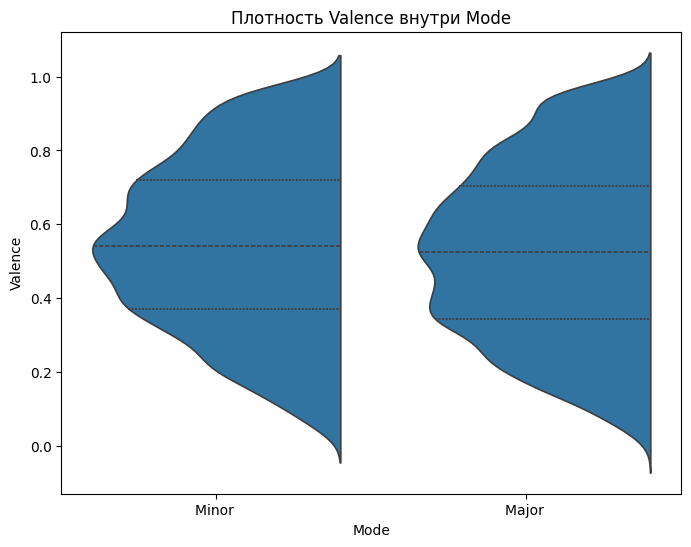

In [43]:
plt.figure(figsize=(8, 6))
sns.violinplot(x='Mode', y='Valence', data=df_mood, split=True, inner="quart")
plt.title('Плотность Valence внутри Mode')
plt.xticks([0, 1], ['Minor ', 'Major '])
plt.show()


In [44]:
major_valence = df_mood[df_mood['Mode'] == 1]['Valence']
minor_valence = df_mood[df_mood['Mode'] == 0]['Valence']

print("Средняя эмоциональная окраска для мажора:", major_valence.sum()/len(major_valence))
print("Средняя эмоциональная окраска для минора:", minor_valence.sum()/len(minor_valence))


f_stat, f_p_value = stats.levene(major_valence, minor_valence) 

print(f"P-value (F-тест): {f_p_value:.4f}")

t_stat, t_p_value = stats.ttest_ind(major_valence, minor_valence, equal_var=(f_p_value > 0.05))

print(f"T-statistic: {t_stat:.4f}")
print(f"P-value (T-test): {t_p_value:.4f}")


print('\n\nТоп 5 самых веселых минорных песен:\n')
for i in range(5):
    print(f">{df_minor_high['Name'][i]}")


print('\n\nТоп 5 самых грустных мажорных песен:\n')
for i in range(5):
    print(f">{df_major_low['Name'][i]}")

Средняя эмоциональная окраска для мажора: 0.5251711728980831
Средняя эмоциональная окраска для минора: 0.5427625398724083
P-value (F-тест): 0.0033
T-statistic: -5.5052
P-value (T-test): 0.0000


Топ 5 самых веселых минорных песен:

>Suflet de bagabont - Cover Andrei Banuta
>Tigrinho
>Enfermera
>La Enfermera
>Vispera de Año Nuevo


Топ 5 самых грустных мажорных песен:

>White Noise Sleeping Aid to Help My Baby Fall Asleep, Sleep Through the Night
>Oceaan
>Who's There?
>True Love
>NOSE CANDY


In [45]:
print('''В данном наборе данных музыкальный лад никак не влияет на эмоциональную окраску. (Так как между мажором и минором нет резкой разницы) 
Люди одинаково часто пишут «грустный» мажор и «веселый» минор.
Из этого следует, что в популярной музыке нет строгого правила, что мажор — это всегда весело, а минор — грустно.
Статистически мажор и минор не только различаются по настроению, но и имеют разный характер разброса, так как в одной из групп треки более разношёрстные по эмоциям.''')

В данном наборе данных музыкальный лад никак не влияет на эмоциональную окраску. (Так как между мажором и минором нет резкой разницы) 
Люди одинаково часто пишут «грустный» мажор и «веселый» минор.
Из этого следует, что в популярной музыке нет строгого правила, что мажор — это всегда весело, а минор — грустно.
Статистически мажор и минор не только различаются по настроению, но и имеют разный характер разброса, так как в одной из групп треки более разношёрстные по эмоциям.


Выбраны треки для анализа: ['Bila Memang Kamu', 'Heeriye (feat. Arijit Singh)', 'L']


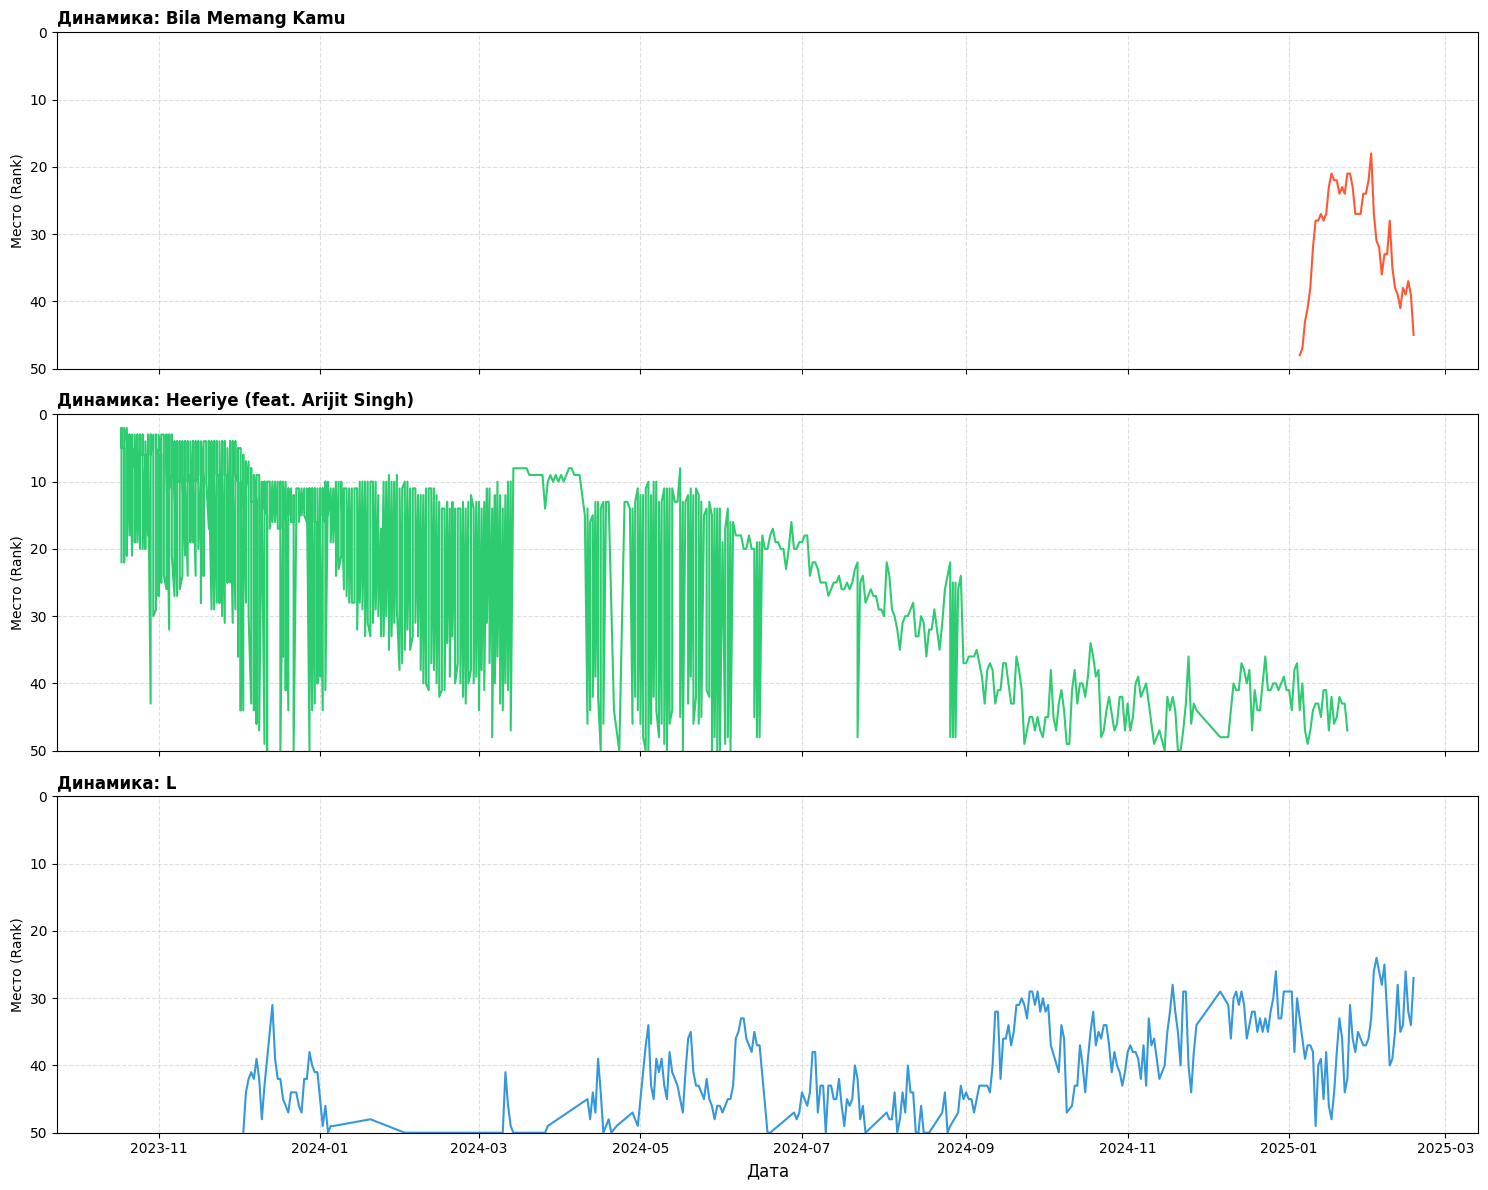

In [46]:
df_new['snapshot_date'] = pd.to_datetime(df_new['snapshot_date'])


names_2023 = set(df_new[df_new['snapshot_date'].dt.year == 2023]['name'])
names_2024 = set(df_new[df_new['snapshot_date'].dt.year == 2024]['name'])
names_2025 = set(df_new[df_new['snapshot_date'].dt.year == 2025]['name'])


long_term_hits = list(names_2023 and names_2024 and names_2025)

if len(long_term_hits) < 3:
    print(f"Найдено всего {len(long_term_hits)} треков за 3 года. Беру их.")
    selected_tracks = long_term_hits
else:
    selected_tracks = long_term_hits[0:3]
    print(f"Выбраны треки для анализа: {selected_tracks}")

fig, axes = plt.subplots(len(selected_tracks), 1, figsize=(15, 12), sharex=True)

colors = ['#FF5733', '#2ECC71', '#3498DB']

for i, track in enumerate(selected_tracks):

    track_data = df_new[df_new['name'] == track].sort_values('snapshot_date')
    

    axes[i].plot(track_data['snapshot_date'], 
                track_data['daily_rank'], 
                color=colors[i], 
                linewidth=1.5,
                label=track)
    

    axes[i].set_ylim(50, 0) 
    axes[i].set_ylabel('Место (Rank)')
    axes[i].grid(True, linestyle='--', alpha=0.4)
    
    axes[i].set_title(f"Динамика: {track}", loc='left', fontsize=12, fontweight='bold')


plt.xlabel('Дата', fontsize=12)
plt.xticks(rotation=0) 


plt.tight_layout()
plt.show()

In [47]:
df_new['snapshot_date'] = pd.to_datetime(df_new['snapshot_date'])
df_new['year_month'] = df_new['snapshot_date'].dt.to_period('M')

all_months = pd.period_range(start='2023-01', end='2025-12', freq='M')
total_required_months = len(all_months)

track_monthly_counts = df_new.groupby('name')['year_month'].nunique()

long_term_hits = track_monthly_counts[track_monthly_counts == total_required_months].index.tolist()

if len(long_term_hits) == 0:
    print("Треков, присутствующих во ВСЕХ месяцах с 2023 по 2025, не найдено.")

    selected_tracks = []
elif len(long_term_hits) < 3:
    print(f"Найдено всего {len(long_term_hits)} треков-долгожителей. Беру их: {long_term_hits}")
    selected_tracks = long_term_hits
else:
    selected_tracks = long_term_hits[:3]
    print(f"Выбраны топ-3 трека для анализа: {selected_tracks}")

if selected_tracks:
    fig, axes = plt.subplots(len(selected_tracks), 1, figsize=(15, 12), sharex=True)

    if len(selected_tracks) == 1: axes = [axes]
    
    colors = ['#FF5733', '#2ECC71', '#3498DB']

    for i, track in enumerate(selected_tracks):
        track_data = df_new[df_new['name'] == track].sort_values('snapshot_date')
        
        axes[i].plot(track_data['snapshot_date'], 
                    track_data['daily_rank'], 
                    color=colors[i], 
                    linewidth=1.5)
        
        axes[i].set_ylim(50, 0)
        axes[i].set_ylabel('Место (Rank)')
        axes[i].grid(True, linestyle='--', alpha=0.4)
        axes[i].set_title(f"Динамика: {track}", loc='left', fontsize=12, fontweight='bold')

    plt.xlabel('Дата', fontsize=12)
    plt.tight_layout()
    plt.show()

Треков, присутствующих во ВСЕХ месяцах с 2023 по 2025, не найдено.
